<a href="https://colab.research.google.com/github/ehfk45/Colab-/blob/main/%EB%B6%84%ED%8F%AC%EB%B3%80%ED%99%94_KBinsDiscretizer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

평균 : 5780.0
중앙값 : 4250.0


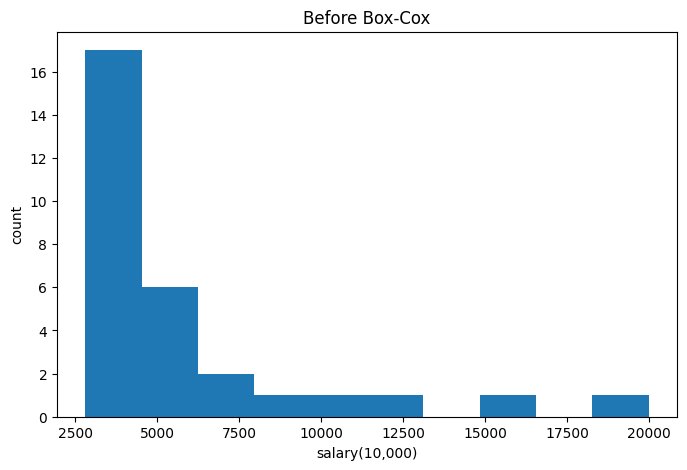

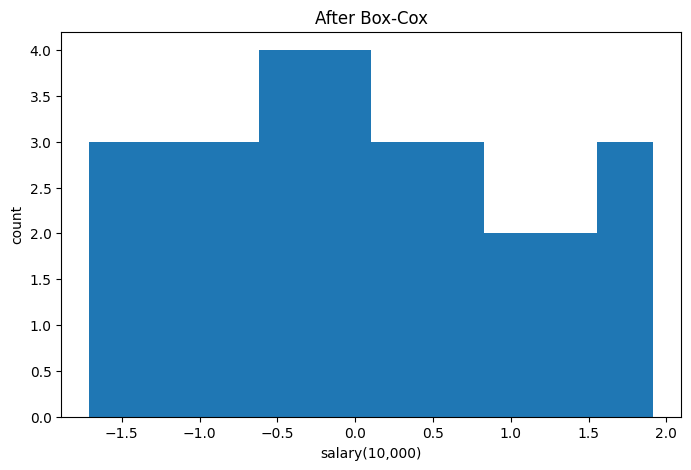

In [ ]:
# Box-Cox: 1964년에 제안된 변환 방법으로, 양수 데이터만 처리할 수 있다.
# Yeo-Johnson: 2000년에 제안된 변환 방법으로, Box-Cox와 비슷한 목적을 가지면서
# 0과 음수 데이터도 처리할 수 있도록 확장한 방법이다.
# 다음의 salary 데이터 변수는 양수만 존재하므로 두방법이 동일한 결과를 만든다

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PowerTransformer


# --------------------------------
# 1. 30명의 직장인 연봉 데이터
# --------------------------------
df = pd.DataFrame({
    'salary': [
        2800, 2900, 3000, 3100, 3200,
        3300, 3400, 3500, 3600, 3700,
        3800, 3900, 4000, 4100, 4200,
        4300, 4500, 4700, 4900, 5200,
        5500, 5800, 6200, 6800, 7500,
        8500, 10000, 12000, 15000, 20000
    ]
})

# display(df)


# --------------------------------
# 2. 변환 전 데이터 탐색
# --------------------------------
print("평균 :", df['salary'].mean())
print("중앙값 :", df['salary'].median())


# --------------------------------
# 3. 변환 전 히스토그램
# --------------------------------
plt.figure(figsize=(8, 5))

plt.hist(df['salary'], bins=10)

plt.xlabel('salary(10,000)')
plt.ylabel('count')
plt.title('Before Box-Cox')

plt.show()


# --------------------------------
# 4. Box-Cox 변환
# --------------------------------
pt = PowerTransformer(method='box-cox')
# pt = PowerTransformer(method='yeo-johnson')

salary_boxcox = pt.fit_transform(df[['salary']])


# 변환 결과를 새로운 컬럼으로 추가
df['salary_boxcox'] = salary_boxcox


# --------------------------------
# 5. 변환 후 데이터 탐색
# --------------------------------
# display(df)


# --------------------------------
# 6. 변환 후 히스토그램
# --------------------------------
plt.figure(figsize=(8, 5))

plt.hist(df['salary_boxcox'], bins=10)

plt.xlabel('salary(10,000)')
plt.ylabel('count')
plt.title('After Box-Cox')

plt.show()


===== 1. 원본 데이터 (LinearRegression) =====
결정계수 R² : -0.5109

===== 2. Yeo-Johnson 변환 후 (LinearRegression) =====
결정계수 R² : 0.8291


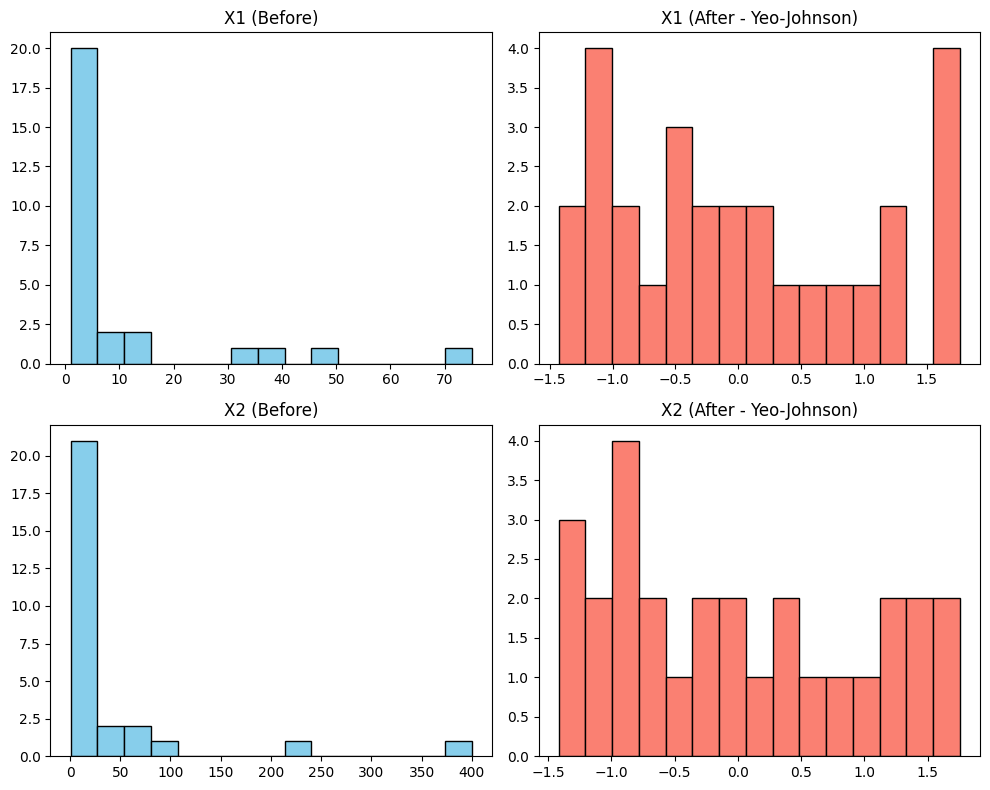

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PowerTransformer
from sklearn.metrics import r2_score


# -------------------------------------------------------------------
# 1. 실제 샘플 데이터 정의 (NumPy 사용 X)
# -------------------------------------------------------------------
df = pd.DataFrame({
    'X1': [
        1.1, 1.2, 1.3, 1.5, 1.8, 2.0, 2.3, 2.7, 3.0, 3.5,
        4.0, 5.2, 6.8, 9.0, 12.5, 18.0, 25.0, 40.0, 75.0, 150.0,
        1.0, 1.4, 1.6, 2.1, 2.5, 3.2, 4.5, 7.5, 15.0, 35.0,
        1.2, 1.7, 2.2, 2.9, 3.8, 5.5, 8.5, 20.0, 50.0, 110.0
    ],
    'X2': [
        0.5, 0.8, 1.1, 1.4, 2.0, 2.5, 3.2, 4.0, 5.5, 7.0,
        10.0, 14.0, 22.0, 35.0, 60.0, 95.0, 140.0, 230.0, 400.0, 800.0,
        0.6, 1.0, 1.3, 1.8, 2.8, 4.8, 8.0, 18.0, 45.0, 100.0,
        0.7, 1.2, 1.9, 3.0, 5.0, 9.0, 16.0, 30.0, 80.0, 200.0
    ],
    'y': [
        12.1, 13.5, 14.2, 15.8, 17.1, 18.3, 19.5, 21.0, 22.4, 24.1,
        25.8, 28.2, 31.0, 34.2, 37.9, 41.5, 45.1, 50.3, 57.8, 66.2,
        11.5, 15.1, 16.2, 18.7, 20.5, 23.0, 27.1, 32.5, 39.1, 48.0,
        13.0, 16.5, 19.0, 21.8, 24.9, 28.8, 33.0, 42.1, 52.0, 62.5
    ]
})

# -------------------------------------------------------------------
# 2. X, y 분리 및 학습 / 테스트 데이터 분리
# -------------------------------------------------------------------
X = df[['X1', 'X2']]
y = df['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# -------------------------------------------------------------------
# 3. 원본 데이터 → 선형회귀(LinearRegression)
# -------------------------------------------------------------------
lr = LinearRegression()
lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)
r2_original = r2_score(y_test, pred_lr)

print("\n===== 1. 원본 데이터 (LinearRegression) =====")
print("결정계수 R² :", round(r2_original, 4))

# -------------------------------------------------------------------
# 4. Yeo-Johnson 변환
# -------------------------------------------------------------------
pt = PowerTransformer(method='yeo-johnson')

X_train_yj = pt.fit_transform(X_train)
X_test_yj = pt.transform(X_test)

# -------------------------------------------------------------------
# 5. Yeo-Johnson 변환 후 → 선형회귀(LinearRegression)
# -------------------------------------------------------------------
lr_yj = LinearRegression()
lr_yj.fit(X_train_yj, y_train)

pred_yj = lr_yj.predict(X_test_yj)
r2_yj = r2_score(y_test, pred_yj)

print("\n===== 2. Yeo-Johnson 변환 후 (LinearRegression) =====")
print("결정계수 R² :", round(r2_yj, 4))


# ===================================================================
# 6. [추가] 분포 변환 전/후 히스토그램 비교 (심플버전)
# ===================================================================
# 변환 후 데이터를 보기 편하게 DataFrame으로 변환
X_train_yj_df = pd.DataFrame(X_train_yj, columns=['X1', 'X2'])


fig = plt.figure(figsize=(10, 8))

axes1 = fig.add_subplot(2, 2, 1)
axes2 = fig.add_subplot(2, 2, 2)
axes3 = fig.add_subplot(2, 2, 3)
axes4 = fig.add_subplot(2, 2, 4)

# X1 변환 전/후
axes1.hist(X_train['X1'], bins=15, color='skyblue', edgecolor='black')
axes1.set_title('X1 (Before)')

axes2.hist(X_train_yj_df['X1'], bins=15, color='salmon', edgecolor='black')
axes2.set_title('X1 (After - Yeo-Johnson)')

# X2 변환 전/후
axes3.hist(X_train['X2'], bins=15, color='skyblue', edgecolor='black')
axes3.set_title('X2 (Before)')

axes4.hist(X_train_yj_df['X2'], bins=15, color='salmon', edgecolor='black')
axes4.set_title('X2 (After - Yeo-Johnson)')

plt.tight_layout()
plt.show()